In [1]:
# ## Joint recall evaluation

import os
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from sklearn.preprocessing import StandardScaler

In [2]:
# Root folders
EXPERIMENTS_ROOT = Path("/data/shared/fsibilla/clean_code/Q0/experiments")
OUTPUT_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/yem_mvam")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Models to scan
MODELS = ["cNF", "NF",
          "TVAE", "CTGAN"]

# Seeds available
SEEDS = [1, 2, 3, 4, 5]

# Dataset subfolder
DATASET_NAME = "yem_mvam"

# Variables used for joint neighbor search
TARGET_COLS = [
    "log_exp_pp", "rCSI", "FCS"
]

ADM1_COL = "adm1name"

# Synthetic filename (always seed-specific)
SYN_FILENAME = "synthetic_pool.csv"

# Default real filename for models whose training set depends on seed
REAL_FILENAME_TEMPLATE = "full_yem_cleaned_used_for_training_seed{seed}.csv"

# For NF and cNF, the real/training set is fixed across seeds.
FIXED_REAL_MODELS = {"NF", "cNF"}
FIXED_REAL_FILENAME = "full_yem_cleaned_used_for_training.csv"

# Radius in the scaled target space
RADIUS = 0.5  

OUTPUT_CSV_ADM1 = OUTPUT_DIR / "recall_gen_true_by_adm1.csv"
OUTPUT_CSV_OVERALL = OUTPUT_DIR / "recall_gen_true_overall.csv"

In [3]:
REFERENCE_REAL_MODEL = "TVAE"   # model from which to read the real/training files
FIXED_REAL_MODELS = {"NF", "cNF"}

def get_real_path(model: str, seed: int):
    """
    Return the correct real/training-set path for a given model and seed.

    Rules:
    - TVAE, CTGAN: use their own seed-specific real file
    - NF, cNF: use the real file from REFERENCE_REAL_MODEL for the same seed
      because the training data are identical across models
    """
    if model in FIXED_REAL_MODELS:
        real_path = (
            EXPERIMENTS_ROOT
            / REFERENCE_REAL_MODEL
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )
    else:
        real_path = (
            EXPERIMENTS_ROOT
            / model
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )

    if not real_path.exists():
        raise FileNotFoundError(
            f"Real training file not found for model={model}, seed={seed}: {real_path}"
        )

    return real_path

In [4]:
def load_real_and_synth(model: str, seed: int):
    """
    Load real and synthetic data for one model and one seed.
    """
    seed_dir = EXPERIMENTS_ROOT / model / DATASET_NAME / "results" / f"seed_{seed}"

    syn_path = seed_dir / SYN_FILENAME
    real_path = get_real_path(model=model, seed=seed)

    if not syn_path.exists():
        raise FileNotFoundError(f"Synthetic file not found: {syn_path}")
    if not real_path.exists():
        raise FileNotFoundError(f"Real file not found: {real_path}")

    syn_df = pd.read_csv(syn_path)
    real_df = pd.read_csv(real_path)

    needed_cols = [ADM1_COL] + TARGET_COLS
    missing_real = [c for c in needed_cols if c not in real_df.columns]
    missing_syn = [c for c in needed_cols if c not in syn_df.columns]

    if missing_real:
        raise ValueError(f"Missing columns in real_df: {missing_real}")
    if missing_syn:
        raise ValueError(f"Missing columns in syn_df: {missing_syn}")

    return real_df, syn_df

In [5]:
def compute_joint_recall_by_adm1(
    real_df: pd.DataFrame,
    syn_df: pd.DataFrame,
    model: str,
    seed: int,
    radius: float = RADIUS,
):
    """
    Compute recall = fraction of true rows that have at least one synthetic neighbor
    within `radius` in the scaled TARGET_COLS space, with exact adm1 match.

    Fast implementation:
    - fit scaler on true data
    - transform true and synthetic targets
    - for each adm1, build one cKDTree on synthetic rows
    - query all true rows of that adm1 with query_ball_point(..., r=radius)

    Returns:
      by_adm1_df with columns:
        model, seed, adm1, recall, matched_real, n_real, n_syn, radius
      overall_dict with columns:
        model, seed, recall, matched_real, n_real, n_syn_total, radius
    """
    cols = [ADM1_COL] + TARGET_COLS

    real_use = real_df[cols].dropna().copy()
    syn_use = syn_df[cols].dropna().copy()

    if real_use.empty:
        raise ValueError(f"real_df became empty after dropna for model={model}, seed={seed}")
    if syn_use.empty:
        raise ValueError(f"syn_df became empty after dropna for model={model}, seed={seed}")

    # Fit scaling on true data only
    scaler = StandardScaler()
    real_scaled = scaler.fit_transform(real_use[TARGET_COLS].to_numpy(dtype=float))
    syn_scaled = scaler.transform(syn_use[TARGET_COLS].to_numpy(dtype=float))

    real_use = real_use.reset_index(drop=True)
    syn_use = syn_use.reset_index(drop=True)

    real_use["_row_id"] = np.arange(len(real_use))
    syn_use["_row_id"] = np.arange(len(syn_use))

    real_use["_adm1"] = real_use[ADM1_COL].astype(str).to_numpy()
    syn_use["_adm1"] = syn_use[ADM1_COL].astype(str).to_numpy()

    real_use["_scaled"] = list(real_scaled)
    syn_use["_scaled"] = list(syn_scaled)

    common_adm1 = sorted(set(real_use["_adm1"]).intersection(set(syn_use["_adm1"])))
    results = []

    total_real = 0
    total_matched = 0
    total_syn = 0

    for adm1 in common_adm1:
        real_sub = real_use.loc[real_use["_adm1"] == adm1].copy()
        syn_sub = syn_use.loc[syn_use["_adm1"] == adm1].copy()

        n_real = len(real_sub)
        n_syn = len(syn_sub)

        if n_real == 0 or n_syn == 0:
            continue

        x_real = np.vstack(real_sub["_scaled"].to_numpy())
        x_syn = np.vstack(syn_sub["_scaled"].to_numpy())

        tree = cKDTree(x_syn)

        # returns list of neighbor-index lists
        neigh_lists = tree.query_ball_point(x_real, r=radius)
        matched_mask = np.fromiter((len(lst) > 0 for lst in neigh_lists), dtype=bool, count=n_real)

        matched_real = int(matched_mask.sum())
        recall = matched_real / n_real if n_real > 0 else np.nan

        results.append({
            "model": model,
            "seed": seed,
            "adm1": adm1,
            "recall": recall,
            "matched_real": matched_real,
            "n_real": n_real,
            "n_syn": n_syn,
            "radius": radius,
        })

        total_real += n_real
        total_matched += matched_real
        total_syn += n_syn

    # True overall recall in the joint space with exact adm1 match:
    # weighted by number of true rows in each adm1
    overall_recall = total_matched / total_real if total_real > 0 else np.nan

    by_adm1_df = pd.DataFrame(results)

    overall_dict = {
        "model": model,
        "seed": seed,
        "recall": overall_recall,
        "matched_real": total_matched,
        "n_real": total_real,
        "n_syn_total": total_syn,
        "radius": radius,
    }

    return by_adm1_df, overall_dict

In [6]:
all_results_adm1 = []
all_results_overall = []

for model in MODELS:
    for seed in SEEDS:
        print(f"Processing model={model}, seed={seed} ...")
        real_df, syn_df = load_real_and_synth(model=model, seed=seed)

        recall_adm1_df, recall_overall_row = compute_joint_recall_by_adm1(
            real_df=real_df,
            syn_df=syn_df,
            model=model,
            seed=seed,
            radius=RADIUS,
        )

        all_results_adm1.append(recall_adm1_df)
        all_results_overall.append(recall_overall_row)

recall_results_adm1 = pd.concat(all_results_adm1, ignore_index=True)
recall_results_overall = pd.DataFrame(all_results_overall)

print("By adm1 shape:", recall_results_adm1.shape)
print("Overall shape:", recall_results_overall.shape)

display(recall_results_adm1.head())
display(recall_results_overall.head())

Processing model=cNF, seed=1 ...
Processing model=cNF, seed=2 ...
Processing model=cNF, seed=3 ...
Processing model=cNF, seed=4 ...
Processing model=cNF, seed=5 ...
Processing model=NF, seed=1 ...
Processing model=NF, seed=2 ...
Processing model=NF, seed=3 ...
Processing model=NF, seed=4 ...
Processing model=NF, seed=5 ...
Processing model=TVAE, seed=1 ...
Processing model=TVAE, seed=2 ...
Processing model=TVAE, seed=3 ...
Processing model=TVAE, seed=4 ...
Processing model=TVAE, seed=5 ...
Processing model=CTGAN, seed=1 ...
Processing model=CTGAN, seed=2 ...
Processing model=CTGAN, seed=3 ...
Processing model=CTGAN, seed=4 ...
Processing model=CTGAN, seed=5 ...
By adm1 shape: (430, 8)
Overall shape: (20, 7)


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Abyan,0.979201,1789,1827,1827,0.5
1,cNF,1,Ad Dali',0.966626,1593,1648,1648,0.5
2,cNF,1,Aden,0.967784,1472,1521,1521,0.5
3,cNF,1,Al Bayda,0.987290,2641,2675,2675,0.5
4,cNF,1,Al Hodeidah,0.982159,4404,4484,4484,0.5


,model,seed,recall,matched_real,n_real,n_syn_total,radius
0,cNF,1,0.980659,53644,54702,54702,0.5
1,cNF,2,0.985668,53918,54702,54702,0.5
2,cNF,3,0.977606,53477,54702,54702,0.5
3,cNF,4,0.983456,53797,54702,54702,0.5
4,cNF,5,0.982597,53750,54702,54702,0.5


In [7]:
recall_results_adm1.to_csv(OUTPUT_CSV_ADM1, index=False)
recall_results_overall.to_csv(OUTPUT_CSV_OVERALL, index=False)

print(f"Saved by-adm1 recall to: {OUTPUT_CSV_ADM1}")
print(f"Saved overall recall to: {OUTPUT_CSV_OVERALL}")

Saved by-adm1 recall to: /data/shared/fsibilla/clean_code/Q0/recall/yem_mvam/recall_gen_true_by_adm1.csv
Saved overall recall to: /data/shared/fsibilla/clean_code/Q0/recall/yem_mvam/recall_gen_true_overall.csv


## Visualize

In [8]:
# ## Visualizza

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED_TO_PLOT = 1

RECALL_ADM1_CSV = OUTPUT_DIR / "recall_gen_true_by_adm1.csv"
RECALL_OVERALL_CSV = OUTPUT_DIR / "recall_gen_true_overall.csv"

recall_adm1 = pd.read_csv(RECALL_ADM1_CSV)
recall_overall = pd.read_csv(RECALL_OVERALL_CSV)

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}



In [9]:
# Mean ± std across seeds
plot_df = (
    recall_overall
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        n_seeds=("recall", "count"),
    )
)

plot_df["recall_std"] = plot_df["recall_std"].fillna(0.0)
plot_df

,model,recall_mean,recall_std,n_seeds
0,CTGAN,0.964243,0.005111,5
1,NF,0.982662,0.002870,5
2,TVAE,0.805517,0.110538,5
3,cNF,0.981997,0.003043,5


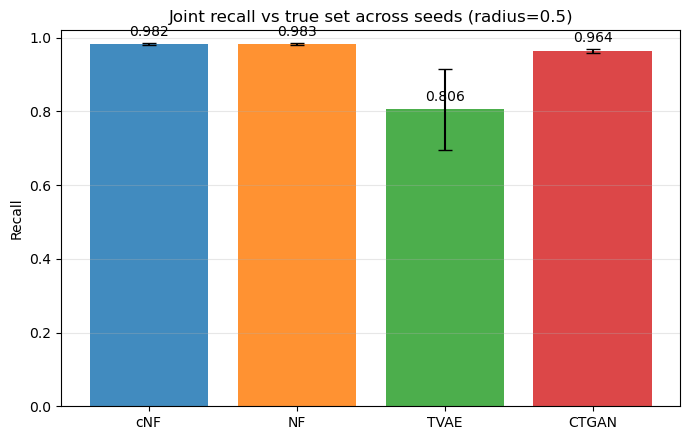

In [10]:
MODEL_ORDER = ["cNF", "NF", "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in plot_df["model"].unique()]

plot_df = plot_df.set_index("model").loc[MODEL_ORDER].reset_index()

fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(plot_df))
y = plot_df["recall_mean"].to_numpy()
yerr = plot_df["recall_std"].to_numpy()
colors = [MODEL_COLORS.get(m, "gray") for m in plot_df["model"]]

ax.bar(x, y, yerr=yerr, capsize=5, color=colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"])
ax.set_ylim(0, 1.02)
ax.set_ylabel("Recall")
ax.set_title(f"Joint recall vs true set across seeds (radius={RADIUS})")
ax.grid(axis="y", alpha=0.3)

for xi, yi in zip(x, y):
    ax.text(xi, yi + 0.015, f"{yi:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Aggregate by model and adm1 across seeds
plot_adm1 = (
    recall_adm1
    .groupby(["model", "adm1"], as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        n_seeds=("recall", "count"),
        n_real_mean=("n_real", "mean"),
    )
)

plot_adm1["recall_std"] = plot_adm1["recall_std"].fillna(0.0)
plot_adm1 = plot_adm1.sort_values(["adm1", "model"]).reset_index(drop=True)

display(plot_adm1.head(20))

,model,adm1,recall_mean,recall_std,n_seeds,n_real_mean
0,CTGAN,Abyan,0.961248,0.008358,5,1827.0
1,NF,Abyan,0.976355,0.003700,5,1827.0
2,TVAE,Abyan,0.774494,0.267023,5,1827.0
3,cNF,Abyan,0.978763,0.004334,5,1827.0
4,CTGAN,Ad Dali',0.970388,0.004918,5,1648.0
5,NF,Ad Dali',0.977549,0.006465,5,1648.0
6,TVAE,Ad Dali',0.814442,0.165803,5,1648.0
7,cNF,Ad Dali',0.979005,0.007707,5,1648.0
8,CTGAN,Aden,0.959632,0.009681,5,1521.0
9,NF,Aden,0.974096,0.004977,5,1521.0


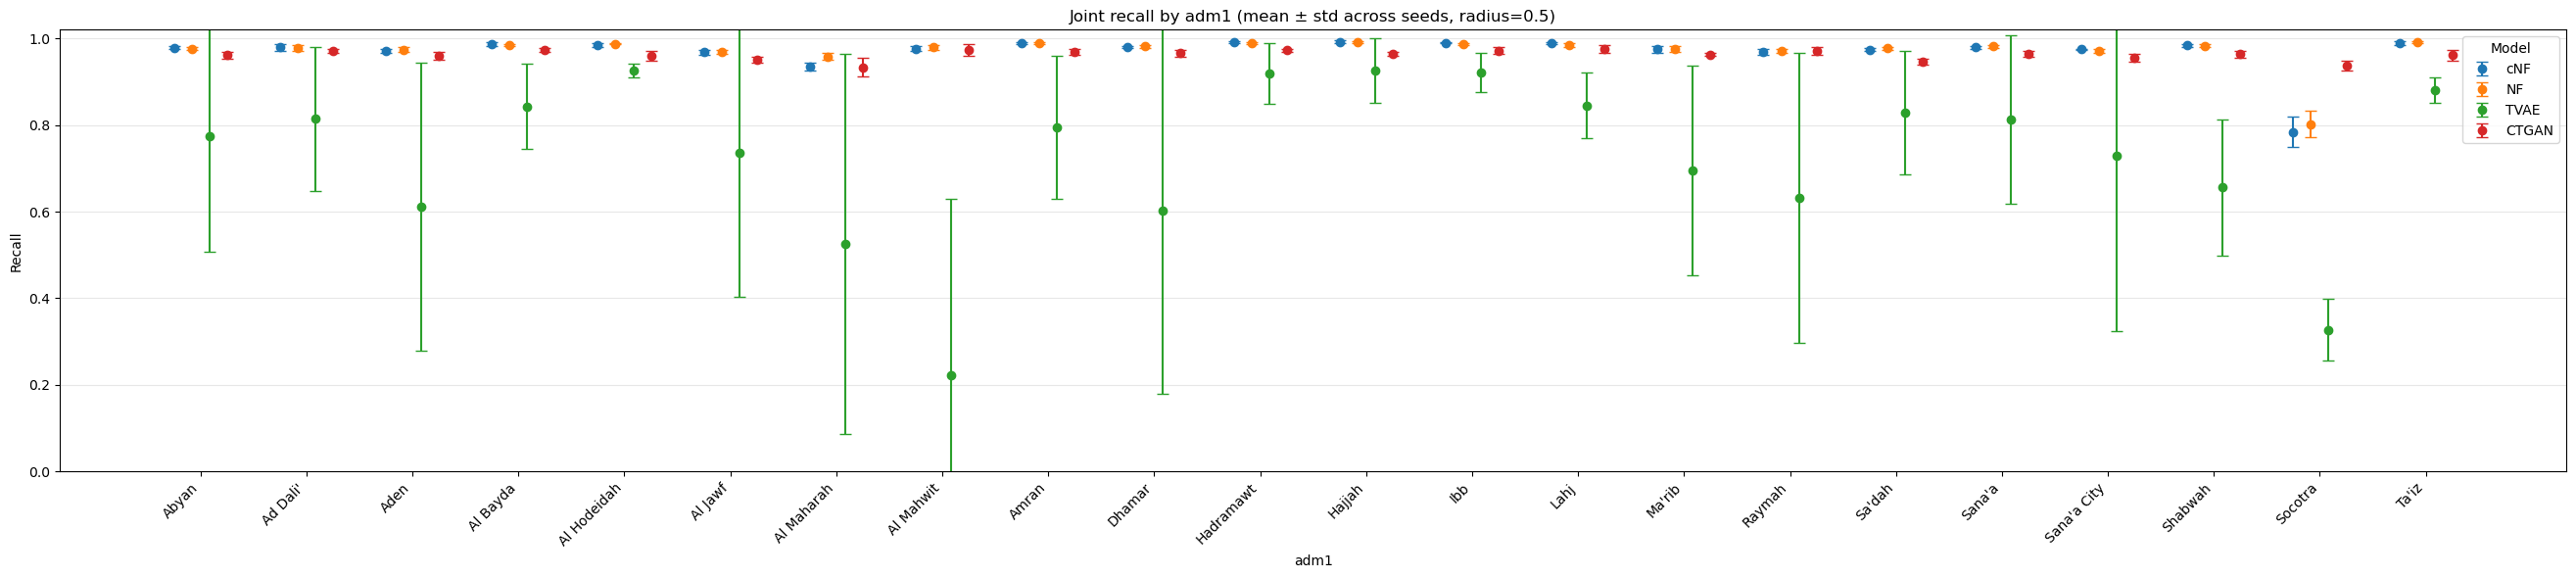

In [12]:
import matplotlib.pyplot as plt
import numpy as np

MODEL_ORDER = ["cNF", "NF", "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in plot_adm1["model"].unique()]

adm1_order = sorted(plot_adm1["adm1"].unique())

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

fig, ax = plt.subplots(figsize=(max(10, len(adm1_order) * 1.2), 6))

x = np.arange(len(adm1_order))
offsets = np.linspace(-0.25, 0.25, len(MODEL_ORDER))

for offset, model in zip(offsets, MODEL_ORDER):
    sub = (
        plot_adm1.loc[plot_adm1["model"] == model, ["adm1", "recall_mean", "recall_std"]]
        .set_index("adm1")
        .reindex(adm1_order)
        .reset_index()
    )

    ax.errorbar(
        x + offset,
        sub["recall_mean"].to_numpy(),
        yerr=sub["recall_std"].to_numpy(),
        fmt="o",
        capsize=4,
        label=model,
        color=MODEL_COLORS.get(model, "gray"),
    )

ax.set_xticks(x)
ax.set_xticklabels(adm1_order, rotation=45, ha="right")
ax.set_ylim(0, 1.02)
ax.set_ylabel("Recall")
ax.set_xlabel("adm1")
ax.set_title(f"Joint recall by adm1 (mean ± std across seeds, radius={RADIUS})")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Model")

plt.tight_layout()
plt.show()